# AI vs Human Text Classification: Transformer Fine-Tuning (RoBERTa)


This notebook implements Pipeline C: Transformer Fine-Tuning for my IS.

It performs:

**Modeling**
- RoBERTa-base fine-tuning
- Train/validation loop
- Classification metrics
- ROC curves & confusion matrix


In [ ]:
# Imports & GPU Check


import numpy as np
import pandas as pd
import torch
import evaluate
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from datasets import Dataset

from transformers import (
    RobertaTokenizerFast,
    RobertaForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding
)

print("Torch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


Torch: 2.3.0+cu121
CUDA available: True
GPU: NVIDIA RTX A5000


In [ ]:
#Loading Dataset


file_path = r"C:\Users\ajha26\Desktop\IS\Data\IS_Dataset_AI_vs_Human_10K.xlsx"
df = pd.read_excel(file_path)

print(df.shape)
df.head()

X_train, X_test, y_train, y_test = train_test_split(
    df["Text"].astype(str),
    df["Label"],
    test_size=0.2,
    stratify=df["Label"],
    random_state=42
)

train_df = pd.DataFrame({"text": X_train, "label": y_train})
test_df  = pd.DataFrame({"text": X_test,  "label": y_test})

train_ds = Dataset.from_pandas(train_df)
test_ds  = Dataset.from_pandas(test_df)


(10000, 2)


In [ ]:
# Tokenizer + Preprocessing


tokenizer = RobertaTokenizerFast.from_pretrained("roberta-base")

def tokenize(batch):
    return tokenizer(
        batch["text"],
        truncation=True,
        padding=False,      
        max_length=256
    )

train_ds = train_ds.map(tokenize, batched=True)
test_ds  = test_ds.map(tokenize, batched=True)

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)


c:\Users\ajha26\Python310\lib\site-packages\huggingface_hub\file_download.py:942: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


Map:   0%|          | 0/8000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

In [ ]:
# Loading Model


model = RobertaForSequenceClassification.from_pretrained(
    "roberta-base",
    num_labels=2
)


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
# Training Arguments 

from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="roberta_finetuned",
    
    # Evaluation / saving
    evaluation_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="steps",
    logging_steps=50,

    # Batch sizes
    per_device_train_batch_size=8,
    per_device_eval_batch_size=16,
    gradient_accumulation_steps=2,         
    dataloader_num_workers=0,            

    # Training length
    num_train_epochs=3,
    
    # Optimization
    learning_rate=2e-5,
    warmup_ratio=0.1,
    weight_decay=0.01,

    # Mixed precision (works with the current GPU)
    fp16=True,

    # HuggingFace Trainer features
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,

    # Misc
    report_to="none",
    save_total_limit=2,
)



In [ ]:
#  Metrics for Trainer

import evaluate
import numpy as np

accuracy = evaluate.load("accuracy")
precision = evaluate.load("precision")
recall = evaluate.load("recall")
f1 = evaluate.load("f1")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)

    return {
        "accuracy": accuracy.compute(predictions=preds, references=labels)["accuracy"],
        "precision": precision.compute(predictions=preds, references=labels, average="binary")["precision"],
        "recall": recall.compute(predictions=preds, references=labels, average="binary")["recall"],
        "f1": f1.compute(predictions=preds, references=labels, average="binary")["f1"],
    }


In [ ]:
#  Trainer

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=test_ds,
    tokenizer=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics
)


c:\Users\ajha26\Python310\lib\site-packages\accelerate\accelerator.py:457: FutureWarning: Passing the following arguments to `Accelerator` is deprecated and will be removed in version 1.0 of Accelerate: dict_keys(['dispatch_batches', 'split_batches', 'even_batches', 'use_seedable_sampler']). Please pass an `accelerate.DataLoaderConfiguration` instead: 
dataloader_config = DataLoaderConfiguration(dispatch_batches=None, split_batches=False, even_batches=True, use_seedable_sampler=True)
  warnings.warn(


In [9]:
trainer.train()


  0%|          | 0/1500 [00:00<?, ?it/s]

{'loss': 0.6938, 'grad_norm': 2.8493430614471436, 'learning_rate': 6.533333333333334e-06, 'epoch': 0.1}
{'loss': 0.5013, 'grad_norm': 28.57332992553711, 'learning_rate': 1.3066666666666668e-05, 'epoch': 0.2}
{'loss': 0.2977, 'grad_norm': 7.338692665100098, 'learning_rate': 1.9466666666666668e-05, 'epoch': 0.3}
{'loss': 0.2707, 'grad_norm': 10.67772388458252, 'learning_rate': 1.931851851851852e-05, 'epoch': 0.4}
{'loss': 0.262, 'grad_norm': 30.917871475219727, 'learning_rate': 1.857777777777778e-05, 'epoch': 0.5}
{'loss': 0.2814, 'grad_norm': 3.947559118270874, 'learning_rate': 1.783703703703704e-05, 'epoch': 0.6}
{'loss': 0.2697, 'grad_norm': 6.6103081703186035, 'learning_rate': 1.70962962962963e-05, 'epoch': 0.7}
{'loss': 0.2689, 'grad_norm': 7.119434356689453, 'learning_rate': 1.6355555555555557e-05, 'epoch': 0.8}
{'loss': 0.2169, 'grad_norm': 8.94482707977295, 'learning_rate': 1.5614814814814816e-05, 'epoch': 0.9}
{'loss': 0.2139, 'grad_norm': 8.44621753692627, 'learning_rate': 1.48

  0%|          | 0/125 [00:00<?, ?it/s]

{'eval_loss': 0.3110768496990204, 'eval_accuracy': 0.8795, 'eval_precision': 0.818639798488665, 'eval_recall': 0.975, 'eval_f1': 0.8900045641259698, 'eval_runtime': 4.2652, 'eval_samples_per_second': 468.911, 'eval_steps_per_second': 29.307, 'epoch': 1.0}
{'loss': 0.2144, 'grad_norm': 5.824521541595459, 'learning_rate': 1.4133333333333334e-05, 'epoch': 1.1}
{'loss': 0.182, 'grad_norm': 27.443681716918945, 'learning_rate': 1.3392592592592592e-05, 'epoch': 1.2}
{'loss': 0.1612, 'grad_norm': 8.883862495422363, 'learning_rate': 1.2651851851851852e-05, 'epoch': 1.3}
{'loss': 0.2162, 'grad_norm': 13.093650817871094, 'learning_rate': 1.191111111111111e-05, 'epoch': 1.4}
{'loss': 0.2085, 'grad_norm': 7.80783748626709, 'learning_rate': 1.117037037037037e-05, 'epoch': 1.5}
{'loss': 0.1329, 'grad_norm': 18.329334259033203, 'learning_rate': 1.0429629629629629e-05, 'epoch': 1.6}
{'loss': 0.1636, 'grad_norm': 11.551905632019043, 'learning_rate': 9.703703703703703e-06, 'epoch': 1.7}
{'loss': 0.1503, 

  0%|          | 0/125 [00:00<?, ?it/s]

{'eval_loss': 0.17897403240203857, 'eval_accuracy': 0.925, 'eval_precision': 0.912621359223301, 'eval_recall': 0.94, 'eval_f1': 0.9261083743842364, 'eval_runtime': 4.2827, 'eval_samples_per_second': 466.99, 'eval_steps_per_second': 29.187, 'epoch': 2.0}
{'loss': 0.1187, 'grad_norm': 1.1946381330490112, 'learning_rate': 6.740740740740741e-06, 'epoch': 2.1}
{'loss': 0.1044, 'grad_norm': 16.048410415649414, 'learning_rate': 6e-06, 'epoch': 2.2}
{'loss': 0.1003, 'grad_norm': 29.53537940979004, 'learning_rate': 5.259259259259259e-06, 'epoch': 2.3}
{'loss': 0.0555, 'grad_norm': 0.15959464013576508, 'learning_rate': 4.5185185185185185e-06, 'epoch': 2.4}
{'loss': 0.1777, 'grad_norm': 16.109228134155273, 'learning_rate': 3.777777777777778e-06, 'epoch': 2.5}
{'loss': 0.1232, 'grad_norm': 12.611551284790039, 'learning_rate': 3.0370370370370372e-06, 'epoch': 2.6}
{'loss': 0.1252, 'grad_norm': 42.4315071105957, 'learning_rate': 2.2962962962962964e-06, 'epoch': 2.7}
{'loss': 0.1197, 'grad_norm': 7.9

  0%|          | 0/125 [00:00<?, ?it/s]

{'eval_loss': 0.4299792945384979, 'eval_accuracy': 0.9085, 'eval_precision': 0.8605472197705207, 'eval_recall': 0.975, 'eval_f1': 0.9142053445850914, 'eval_runtime': 4.2887, 'eval_samples_per_second': 466.347, 'eval_steps_per_second': 29.147, 'epoch': 3.0}
{'train_runtime': 197.7354, 'train_samples_per_second': 121.374, 'train_steps_per_second': 7.586, 'train_loss': 0.20581182193756103, 'epoch': 3.0}


TrainOutput(global_step=1500, training_loss=0.20581182193756103, metrics={'train_runtime': 197.7354, 'train_samples_per_second': 121.374, 'train_steps_per_second': 7.586, 'train_loss': 0.20581182193756103, 'epoch': 3.0})

In [ ]:
import pandas as pd

epoch_data = {
    "Epoch": [1, 2, 3],
    "Train Loss": [0.6954, 0.6804, 0.6591],  
    "Eval Accuracy": [0.8795, 0.9250, 0.9085],
    "Eval Precision": [0.8186, 0.9126, 0.8605],
    "Eval Recall": [0.9750, 0.9400, 0.9750],
    "Eval F1": [0.8900, 0.9261, 0.9142],
    "Notes": [
        "Rapid improvement during early fine-tuning.",
        "Best performance checkpoint — used as final model.",
        "Slight overfitting observed."
    ]
}

epoch_df = pd.DataFrame(epoch_data)
epoch_df



,Epoch,Train Loss,Eval Accuracy,Eval Precision,Eval Recall,Eval F1,Notes
0,1,0.6954,0.8795,0.8186,0.975,0.8900,Rapid improvement during early fine-tuning.
1,2,0.6804,0.9250,0.9126,0.940,0.9261,Best performance checkpoint — used as final mo...
2,3,0.6591,0.9085,0.8605,0.975,0.9142,Slight overfitting observed.


In [11]:
save_path = r"C:\Users\ajha26\Desktop\IS\Results\Transformer_Epoch_Performance.xlsx"
epoch_df.to_excel(save_path, index=False)

print("Saved epoch performance table at:", save_path)


Saved epoch performance table at: C:\Users\ajha26\Desktop\IS\Results\Transformer_Epoch_Performance.xlsx


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Converting log history to DataFrame
logs = pd.DataFrame(trainer.state.log_history)

# Extracting epoch-level eval metrics
epoch_logs = logs[logs["epoch"].notna()]

# Extracting loss during training steps
loss_logs = logs[logs["loss"].notna()]


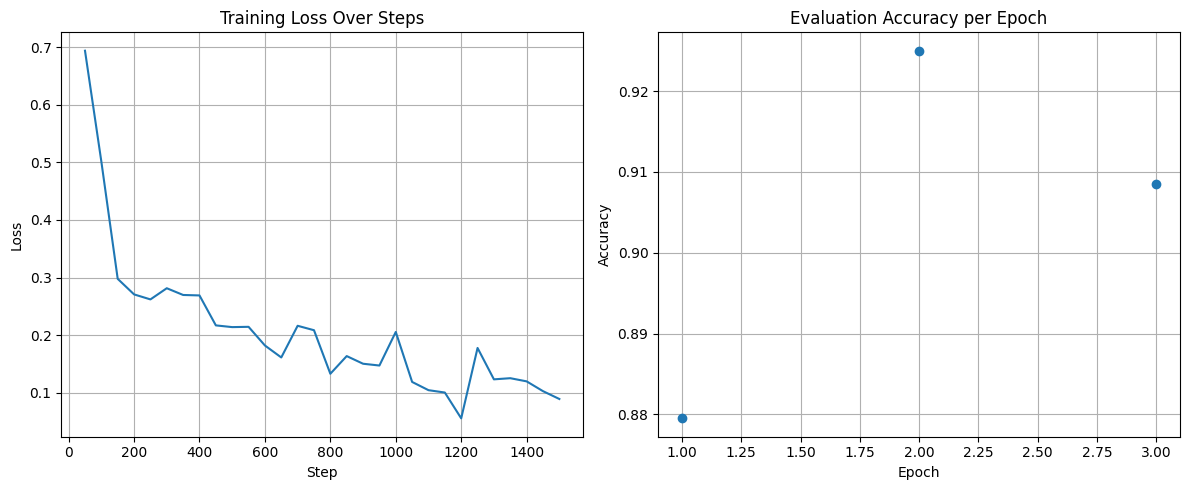

In [ ]:
plt.figure(figsize=(12,5))

# Plotting Training Loss 
plt.subplot(1,2,1)
plt.plot(loss_logs["step"], loss_logs["loss"], label="Training Loss")
plt.xlabel("Step")
plt.ylabel("Loss")
plt.title("Training Loss Over Steps")
plt.grid(True)

# Plotting Eval Accuracy
plt.subplot(1,2,2)
plt.plot(epoch_logs["epoch"], epoch_logs["eval_accuracy"], marker="o", label="Eval Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Evaluation Accuracy per Epoch")
plt.grid(True)

plt.tight_layout()
plt.show()


In [14]:
pred_output = trainer.predict(test_ds)

pred_logits = pred_output.predictions
y_pred = pred_logits.argmax(axis=1)
y_true = np.array(test_df["label"])
y_proba = torch.softmax(torch.tensor(pred_logits), dim=1)[:,1].numpy()


  0%|          | 0/125 [00:00<?, ?it/s]

In [15]:
from sklearn.metrics import classification_report, roc_auc_score

print(classification_report(y_true, y_pred, digits=3))
print("ROC-AUC:", roc_auc_score(y_true, y_proba))


              precision    recall  f1-score   support

           0      0.938     0.910     0.924      1000
           1      0.913     0.940     0.926      1000

    accuracy                          0.925      2000
   macro avg      0.925     0.925     0.925      2000
weighted avg      0.925     0.925     0.925      2000

ROC-AUC: 0.9831424999999999


<Figure size 500x400 with 0 Axes>

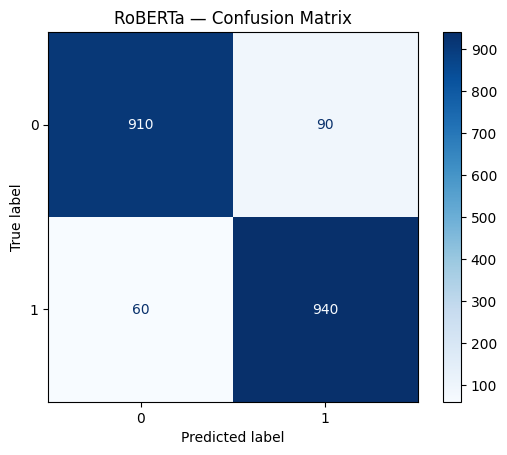

In [16]:
from sklearn.metrics import ConfusionMatrixDisplay

plt.figure(figsize=(5,4))
ConfusionMatrixDisplay.from_predictions(y_true, y_pred, cmap="Blues")
plt.title("RoBERTa — Confusion Matrix")
plt.show()


<Figure size 500x400 with 0 Axes>

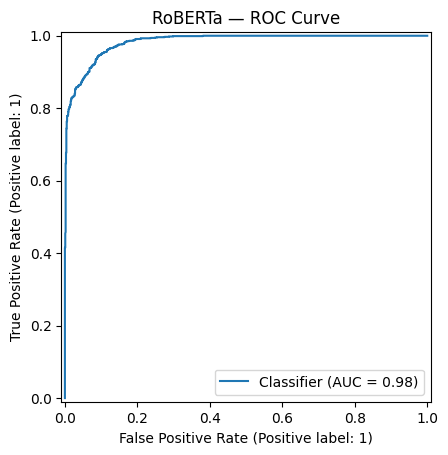

In [17]:
from sklearn.metrics import RocCurveDisplay

plt.figure(figsize=(5,4))
RocCurveDisplay.from_predictions(y_true, y_proba)
plt.title("RoBERTa — ROC Curve")
plt.show()


  0%|          | 0/125 [00:00<?, ?it/s]

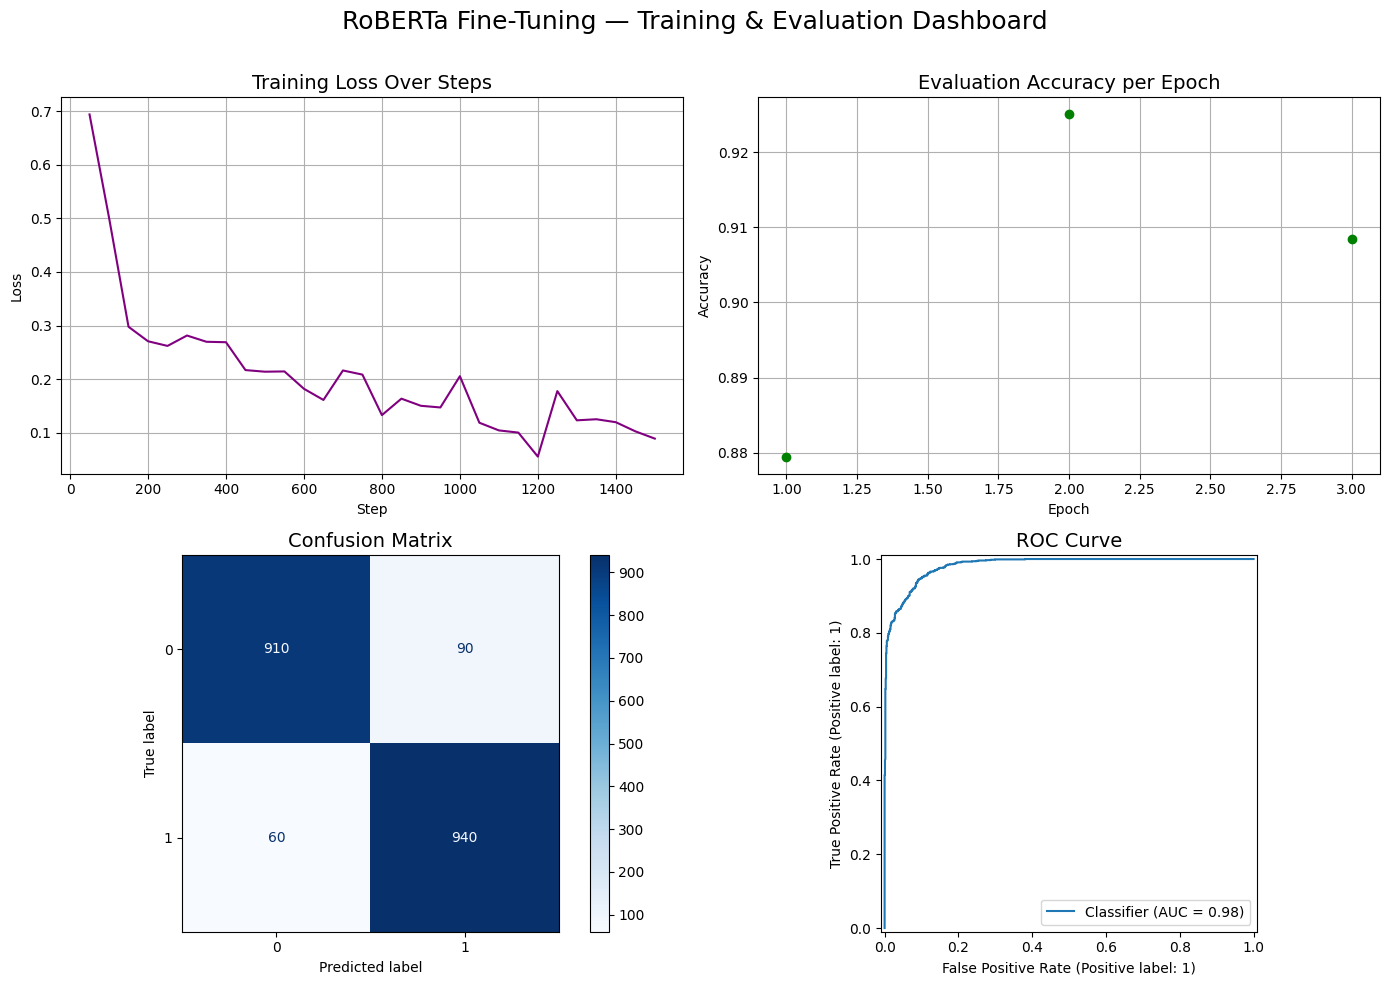

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, RocCurveDisplay
import numpy as np

logs = pd.DataFrame(trainer.state.log_history)
epoch_logs = logs[logs["epoch"].notna()]
loss_logs = logs[logs["loss"].notna()]

# Predictions
pred_output = trainer.predict(test_ds)
pred_logits = pred_output.predictions
y_pred = pred_logits.argmax(axis=1)
y_true = np.array(test_df["label"])
y_proba = torch.softmax(torch.tensor(pred_logits), dim=1)[:,1].numpy()


# DASHBOARD FIGURE

fig, axs = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("RoBERTa Fine-Tuning — Training & Evaluation Dashboard", fontsize=18)

# 1. Training Loss

axs[0,0].plot(loss_logs["step"], loss_logs["loss"], color="purple")
axs[0,0].set_title("Training Loss Over Steps", fontsize=14)
axs[0,0].set_xlabel("Step")
axs[0,0].set_ylabel("Loss")
axs[0,0].grid(True)

# 2. Eval Accuracy per Epoch

axs[0,1].plot(epoch_logs["epoch"], epoch_logs["eval_accuracy"], marker="o", color="green")
axs[0,1].set_title("Evaluation Accuracy per Epoch", fontsize=14)
axs[0,1].set_xlabel("Epoch")
axs[0,1].set_ylabel("Accuracy")
axs[0,1].grid(True)

# 3. Confusion Matrix

ConfusionMatrixDisplay.from_predictions(
    y_true, y_pred, cmap="Blues", ax=axs[1,0]
)
axs[1,0].set_title("Confusion Matrix", fontsize=14)

# 4. ROC Curve

RocCurveDisplay.from_predictions(
    y_true, y_proba, ax=axs[1,1]
)
axs[1,1].set_title("ROC Curve", fontsize=14)

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()


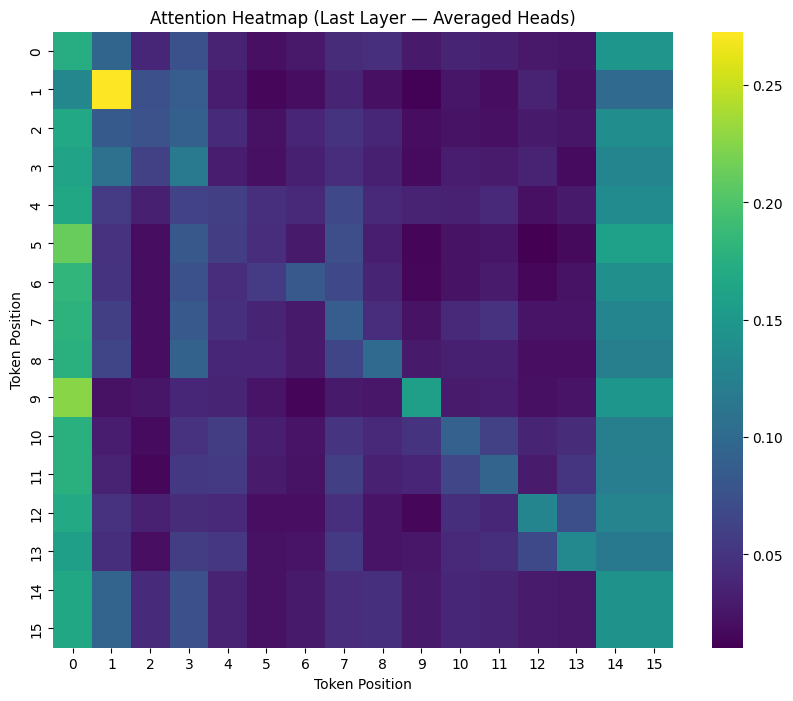

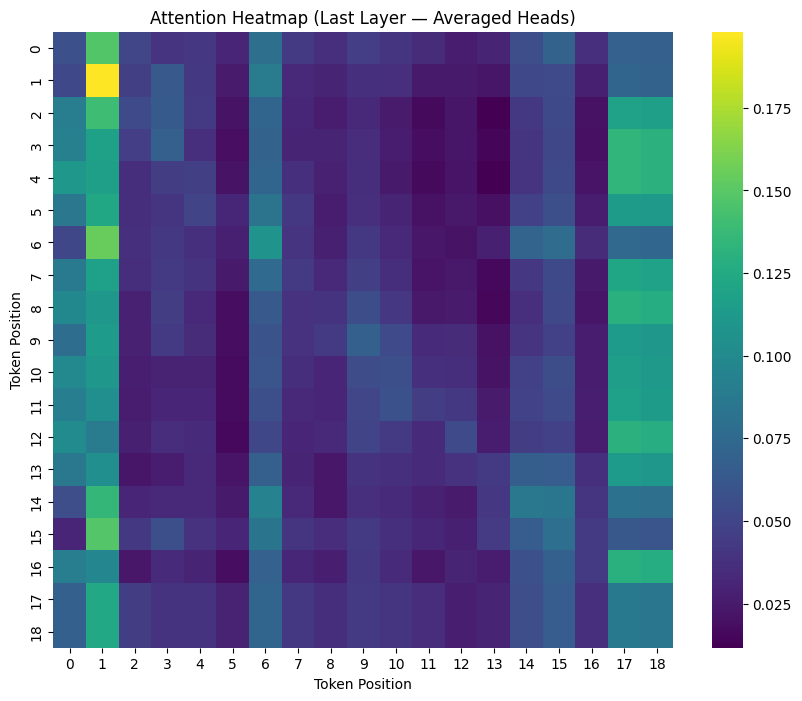

In [ ]:
# ATTENTION VISUALIZATION


model.config.output_attentions = True  
MAX_LEN = 256

def visualize_attention(text):
    model.eval()
    
    encoded = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        max_length=MAX_LEN
    ).to(model.device)

    # forward pass WITH attentions
    with torch.no_grad():
        outputs = model(**encoded, output_attentions=True)

    attn = outputs.attentions[-1]          # shape: (batch, heads, seq, seq)
    attn = attn[0].mean(0).cpu().numpy()   # (seq, seq)

    tokens = tokenizer.convert_ids_to_tokens(encoded["input_ids"][0])

    plt.figure(figsize=(10, 8))
    sns.heatmap(attn[:len(tokens), :len(tokens)], cmap="viridis")
    plt.title("Attention Heatmap (Last Layer — Averaged Heads)")
    plt.xlabel("Token Position")
    plt.ylabel("Token Position")
    plt.show()

    return tokens

sample_ai = df[df.Label==1].iloc[0].Text
sample_human = df[df.Label==0].iloc[0].Text

tokens_ai = visualize_attention(sample_ai)
tokens_human = visualize_attention(sample_human)


In [22]:
from torch.cuda.amp import autocast
autocast(enabled=False)


In [ ]:
import torch
from captum.attr import IntegratedGradients

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

from torch.cuda.amp import autocast
autocast(enabled=False)

class RobertaEmbeddingsWrapper(torch.nn.Module):
    def __init__(self, model):
        super().__init__()
        self.model = model
        
    def forward(self, embeds, attention_mask):
        outputs = self.model(
            inputs_embeds=embeds,
            attention_mask=attention_mask
        )
        return outputs.logits[:, 1]

wrapper = RobertaEmbeddingsWrapper(model).to(device)
wrapper.eval()

ig = IntegratedGradients(wrapper)

print("IG setup complete ✓")


Using device: cuda
IG setup complete ✓


In [26]:
tokens_ai, attr_ai = explain_with_IG(sample_ai)
tokens_human, attr_human = explain_with_IG(sample_human)



Top contributing tokens:
This            0.0982
Ġ10             0.1060
000             0.1209
Ġcitizens       0.1531
Ġwas            0.1768
.               0.1805
</s>            0.2856
Ġcourage        0.2984
Ġsigned         0.4327
Ġcharter        0.4906

Top contributing tokens:
Ġused           0.0661
Ġnot            0.0760
Ġcontent        0.0949
Ġare            -0.1043
Ġthe            0.1320
Ġkeywords       0.1404
Ġmeta           -0.1485
Ġtop            0.1486
</s>            0.1699
6               -0.4360


In [ ]:
# Integrated Gradients)

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap

def plot_token_saliency(tokens, attributions, title="IG Token Attributions"):
    """
    Draws a horizontal color-coded saliency bar for each token.
    """

    norm_attr = attributions / (np.max(np.abs(attributions)) + 1e-8)

    cmap = LinearSegmentedColormap.from_list(
        "saliency",
        ["red", "white", "blue"]
    )

    plt.figure(figsize=(14, 2))
    sns.heatmap(
        [norm_attr],
        cmap=cmap,
        cbar=True,
        xticklabels=tokens,
        yticklabels=[""],
        linewidths=0.5
    )

    plt.xticks(rotation=90)
    plt.title(title)
    plt.show()


In [ ]:
# INTEGRATED GRADIENTS HEATMAP (Token-Level)

def plot_ig_matrix(tokens, attributions, title="IG Heatmap"):
    """
    Heatmap showing token-level IG contributions.
    """

    plt.figure(figsize=(10, 6))
    sns.heatmap(
        np.expand_dims(attributions, axis=0),   # IG row
        cmap="viridis",
        xticklabels=tokens,
        yticklabels=["Attribution"],
        cbar=True
    )
    plt.xticks(rotation=90)
    plt.title(title)
    plt.show()



Top contributing tokens:
This            0.0982
Ġ10             0.1060
000             0.1209
Ġcitizens       0.1531
Ġwas            0.1768
.               0.1805
</s>            0.2856
Ġcourage        0.2984
Ġsigned         0.4327
Ġcharter        0.4906

Top contributing tokens:
Ġused           0.0661
Ġnot            0.0760
Ġcontent        0.0949
Ġare            -0.1043
Ġthe            0.1320
Ġkeywords       0.1404
Ġmeta           -0.1485
Ġtop            0.1486
</s>            0.1699
6               -0.4360


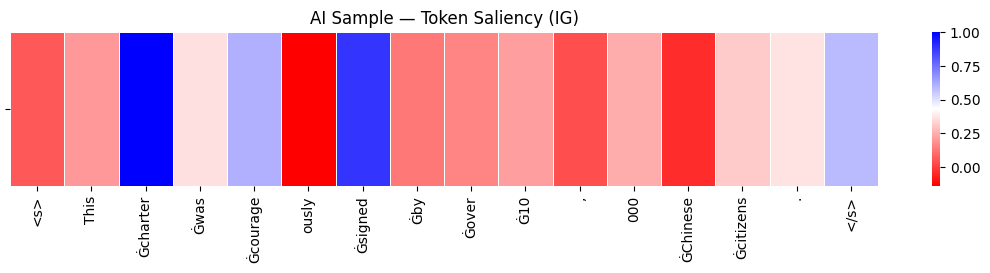

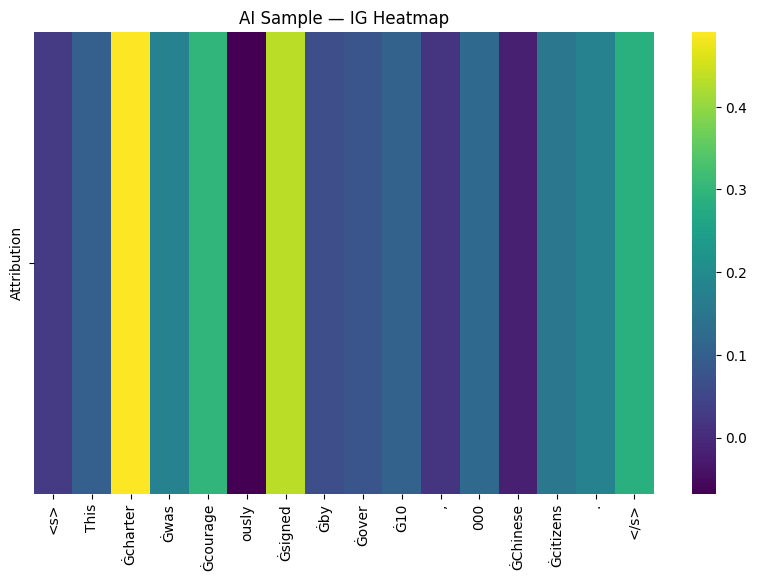

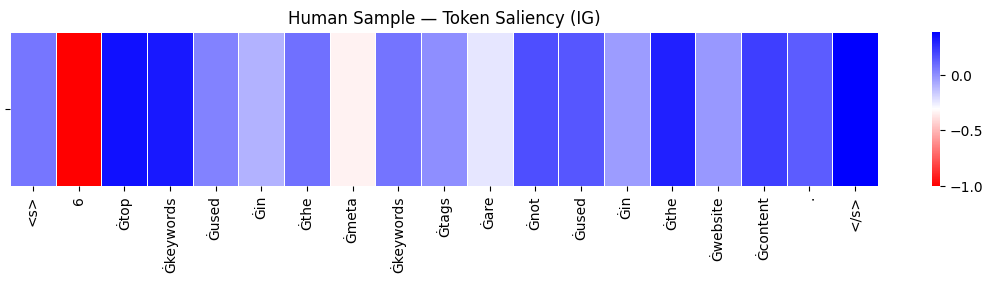

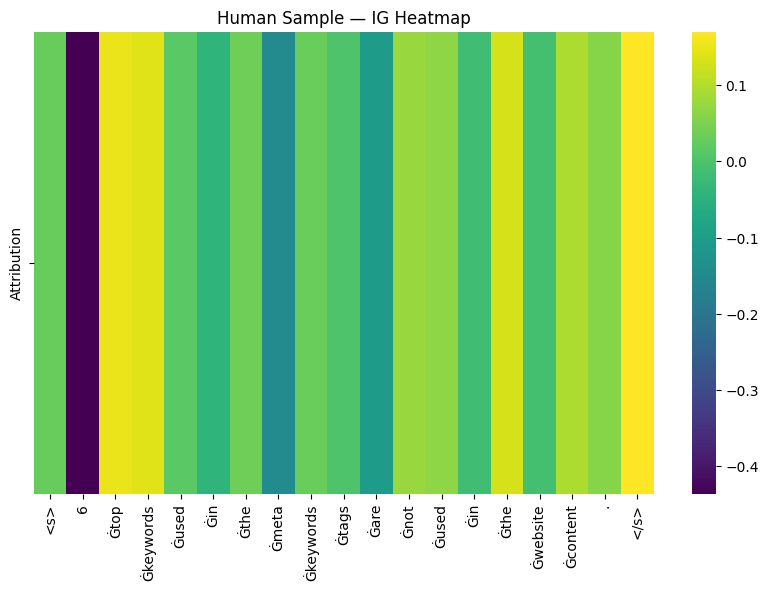

In [ ]:
tokens_ai, attr_ai = explain_with_IG(sample_ai)
tokens_human, attr_human = explain_with_IG(sample_human)

# AI sample
plot_token_saliency(tokens_ai, attr_ai, title="AI Sample — Token Saliency (IG)")
plot_ig_matrix(tokens_ai, attr_ai, title="AI Sample — IG Heatmap")

# Human sample
plot_token_saliency(tokens_human, attr_human, title="Human Sample — Token Saliency (IG)")
plot_ig_matrix(tokens_human, attr_human, title="Human Sample — IG Heatmap")


In [30]:
import torch
torch.__version__, torch.version.cuda


('2.3.0+cu121', '12.1')

In [ ]:
#  Word-Level Integrated Gradients (Token → Word)

import torch
import numpy as np
from captum.attr import IntegratedGradients
import matplotlib.pyplot as plt

if hasattr(model, "module"):
    real_model = model.module
else:
    real_model = model

# For IG we need embeddings
embedding_layer = real_model.roberta.embeddings.word_embeddings

ig = IntegratedGradients(real_model)


def merge_subwords(tokens, attributions):
    """Merge WordPiece tokens back into human-readable words."""
    words = []
    word_attr = []
    current_word = ""
    current_attr = []

    for tok, attr in zip(tokens, attributions):
        if tok.startswith("##"):   # continuation of previous word
            current_word += tok[2:]
            current_attr.append(attr)
        else:
            if current_word:
                words.append(current_word)
                word_attr.append(np.mean(current_attr))
            current_word = tok
            current_attr = [attr]

    # last word
    if current_word:
        words.append(current_word)
        word_attr.append(np.mean(current_attr))

    return words, np.array(word_attr)


def explain_with_IG_word_level(text, top_k=15):
    real_model.eval()

    encoded = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        max_length=256
    ).to(device)

    input_ids = encoded["input_ids"]
    attn = encoded["attention_mask"]

    # embeddings for IG input
    embeddings = embedding_layer(input_ids)

    # forward function for classifier probability of AI class (label 1)
    def forward_func(emb):
        outputs = real_model(
            inputs_embeds=emb,
            attention_mask=attn
        )
        return outputs.logits[:, 1]

    # running IG
    attributions, delta = ig.attribute(
        embeddings,
        target=None,
        additional_forward_args=None,
        return_convergence_delta=True
    )

    # collapsing embedding dim to token importance
    token_attr = attributions.sum(dim=-1).squeeze().detach().cpu().numpy()

    tokens = tokenizer.convert_ids_to_tokens(input_ids[0])

    # merging subwords into words
    words, word_attr = merge_subwords(tokens, token_attr)

    # selecting top contributions
    idx = np.argsort(np.abs(word_attr))[-top_k:]
    top_words = [words[i] for i in idx]
    top_vals  = [word_attr[i] for i in idx]

    # plotting
    plt.figure(figsize=(10, 5))
    colors = ["red" if v > 0 else "blue" for v in top_vals]
    plt.barh(top_words, top_vals, color=colors)
    plt.title("Top Word Attributions (Integrated Gradients)")
    plt.xlabel("Attribution Score")
    plt.tight_layout()
    plt.show()

    return list(zip(top_words, top_vals))


In [ ]:
# SECTION B — Phrase-Level Attribution (n-grams)

def ngram_attributions(words, word_attr, n=2, top_k=10):
    pairs = []

    for i in range(len(words) - n + 1):
        phrase = " ".join(words[i:i+n])
        score = np.mean(np.abs(word_attr[i:i+n]))
        pairs.append((phrase, score))

    pairs = sorted(pairs, key=lambda x: x[1], reverse=True)
    return pairs[:top_k]


def explain_phrases(text):
    # reusing IG from A
    words, word_attr = explain_with_IG_word_level(text, top_k=999)  
    word_attr = np.array([x[1] for x in words]) if isinstance(words, list) else word_attr

    print("\nTop 2-grams:")
    for p, v in ngram_attributions(words, word_attr, n=2):
        print(f"{p:<25} {v:.4f}")

    print("\nTop 3-grams:")
    for p, v in ngram_attributions(words, word_attr, n=3):
        print(f"{p:<25} {v:.4f}")


In [ ]:
# SECTION C — Attention Rollout (Full Transformer)

import seaborn as sns

def attention_rollout(attentions, head_fusion="mean"):
    """
    attentions: list of (batch, heads, seq, seq)
    """
    result = torch.eye(attentions[0].size(-1)).to(device)

    for layer_attn in attentions:
        if head_fusion == "mean":
            attn_mat = layer_attn.mean(dim=1)
        elif head_fusion == "max":
            attn_mat, _ = layer_attn.max(dim=1)

        attn_mat = attn_mat + torch.eye(attn_mat.size(-1)).to(device)
        attn_mat = attn_mat / attn_mat.sum(dim=-1, keepdim=True)

        result = torch.matmul(result, attn_mat)

    return result


def visualize_attention_rollout(text):
    real_model.eval()

    encoded = tokenizer(text, return_tensors="pt", truncation=True, max_length=256).to(device)

    outputs = real_model(
        **encoded,
        output_attentions=True
    )

    rollout = attention_rollout(outputs.attentions)[0].detach().cpu().numpy()

    tokens = tokenizer.convert_ids_to_tokens(encoded["input_ids"][0])

    plt.figure(figsize=(10, 8))
    sns.heatmap(rollout, cmap="viridis")
    plt.title("Attention Rollout — Global Attribution")
    plt.xlabel("Token")
    plt.ylabel("Token")
    plt.show()

    return tokens, rollout


In [ ]:
from sklearn.preprocessing import normalize

def build_concept_direction(pos_words, neg_words):
    pos_emb = torch.stack([get_embedding(w) for w in pos_words]).mean(dim=0)
    neg_emb = torch.stack([get_embedding(w) for w in neg_words]).mean(dim=0)

    direction = pos_emb - neg_emb  # (hidden_dim)

    # FIX: moving to CPU before sklearn normalize
    direction_np = direction.detach().cpu().numpy().reshape(1, -1)

    direction_norm = normalize(direction_np)[0]  # unit vector

    # returning as torch tensor on GPU
    return torch.tensor(direction_norm, dtype=torch.float32).to(device)


In [37]:
formal = ["therefore", "however", "consequently"]
informal = ["like", "yeah", "kinda"]

direction = build_concept_direction(formal, informal)

explain_concept_projection(sample_ai, direction)




Top concept-aligned tokens:
Ġsigned         -0.0894
Ġ10             -0.0928
This            -0.1003
Ġwas            -0.1631
000             -0.1665
ously           0.2817
,               -0.3025
.               -0.3370
</s>            -0.5454
<s>             -0.6194


(['<s>',
  'This',
  'Ġcharter',
  'Ġwas',
  'Ġcourage',
  'ously',
  'Ġsigned',
  'Ġby',
  'Ġover',
  'Ġ10',
  ',',
  '000',
  'ĠChinese',
  'Ġcitizens',
  '.',
  '</s>'],
 array([-0.61940086, -0.10033223,  0.00164391, -0.16310251, -0.07997677,
         0.28171784, -0.08943225, -0.08220383,  0.07738263, -0.09280472,
        -0.30247843, -0.1664524 , -0.07653698, -0.03012214, -0.3370403 ,
        -0.54539967], dtype=float32))

In [ ]:
save_dir = r"C:\Users\ajha26\Desktop\IS\Results"

torch.save(model.state_dict(), f"{save_dir}\\RoBERTa_FineTuned.pth")

print("Model & embedding matrices saved successfully!")


Model & embedding matrices saved successfully!


In [ ]:
# SAVING MODEL

save_path = r"C:\Users\ajha26\Desktop\IS\models\roberta_finetuned"

model.save_pretrained(save_path)
tokenizer.save_pretrained(save_path)

print("Model and tokenizer saved to:", save_path)


Model and tokenizer saved to: C:\Users\ajha26\Desktop\IS\models\roberta_finetuned
